In [47]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")

# 自动找到 train*.csv / test*.csv（兼容 train.csv 或 train (1).csv）
train_path = sorted(DATA_DIR.glob("train*.csv"))[0]
test_path  = sorted(DATA_DIR.glob("test*.csv"))[0]
train_path, test_path
# 读取数据
train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()


Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


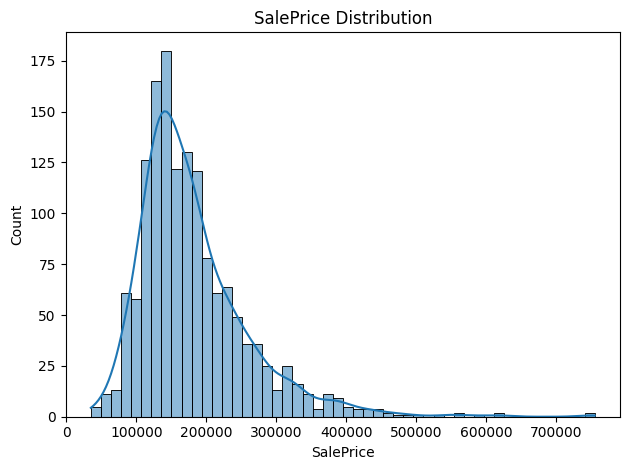

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

IMG_DIR = "images"
os.makedirs(IMG_DIR, exist_ok=True)

# Missing Values Top 20
missing = train.isnull().sum().sort_values(ascending=False)
missing.head(20)

# (SalePrice)
plt.figure()
sns.histplot(train["SalePrice"], kde=True, bins=50)
plt.title("SalePrice Distribution")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/target_hist.png")
plt.show()



In [49]:
import numpy as np

num_cols = train.select_dtypes(include=[np.number]).columns.drop(["SalePrice", "Id"])
cat_cols = train.select_dtypes(exclude=[np.number]).columns

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))
list(cat_cols)[:10]  # See first 10 list


Numeric features: 36
Categorical features: 43


['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1']

✅ Model evaluation (RandomForest + full preprocessing):
RMSLE = 0.1531
MAE   = 17,474.60
RMSE  = 28,581.09
R²    = 0.8935


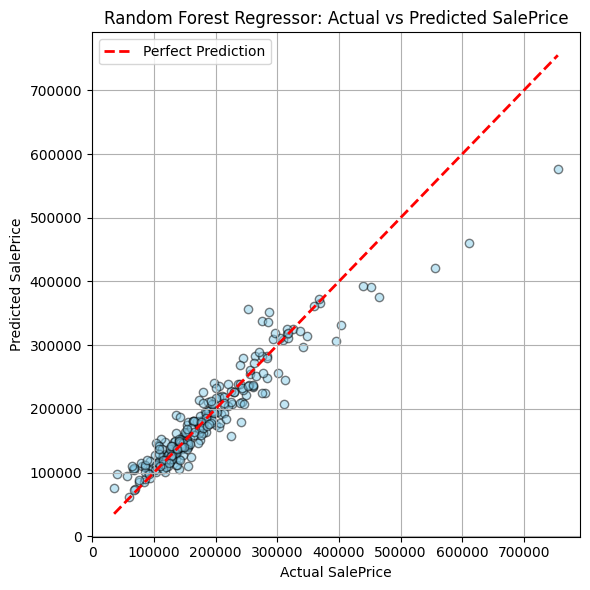

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# ===== Separating features from targets =====
X = train.drop(["SalePrice", "Id"], axis=1)
y = train["SalePrice"]

# ===== Numerical Feature Pipeline =====
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ===== Categorical Feature Pipeline =====
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# ===== Merge Values + Category Processing Flow =====
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)

# ===== Complete build pipeline（include model） =====
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=120,
        random_state=42,
        n_jobs=-1
    ))
])

# ===== Split Training/Validation Set =====
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===== Fitting the model =====
model.fit(X_train, y_train)

# ===== Predict and evaluate =====
preds = model.predict(X_valid)

rmsle = np.sqrt(mean_squared_log_error(y_valid, preds))
mae   = mean_absolute_error(y_valid, preds)
rmse  = np.sqrt(mean_squared_error(y_valid, preds))
r2    = r2_score(y_valid, preds)

print("✅ Model evaluation (RandomForest + full preprocessing):")
print(f"RMSLE = {rmsle:.4f}")
print(f"MAE   = {mae:,.2f}")
print(f"RMSE  = {rmse:,.2f}")
print(f"R²    = {r2:.4f}")

# ===== Plot: Actual vs Predicted SalePrice =====
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_valid, preds, alpha=0.5, color="skyblue", edgecolor="k")
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()],
         'r--', lw=2, label='Perfect Prediction')

plt.title("Random Forest Regressor: Actual vs Predicted SalePrice")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save image to images folder
plt.savefig("images/actual_vs_pred_rf.png")
plt.show()



C:\Users\yenya\AppData\Local\Temp\ipykernel_8128\227668066.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="coolwarm")


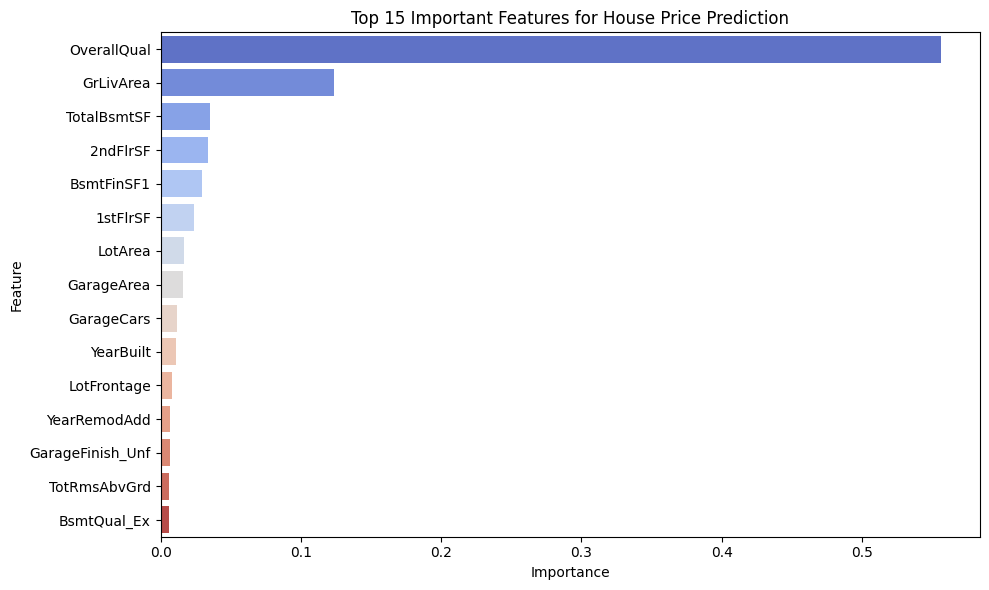

In [51]:
importances = model.named_steps["regressor"].feature_importances_

# Extract the encoded column names
ohe = model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]
cat_features = list(ohe.get_feature_names_out(cat_cols))
all_features = num_cols.tolist() + cat_features

# Sort by descending importance
feat_imp = pd.DataFrame({"Feature": all_features, "Importance": importances})
feat_imp = feat_imp.sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="coolwarm")
plt.title("Top 15 Important Features for House Price Prediction")
plt.tight_layout()
plt.savefig("images/feature_importance.png")
plt.show()


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error
import numpy as np

# ✅ Only retain unmerical features
X_train_num = X_train.select_dtypes(include=np.number)
X_valid_num = X_valid.select_dtypes(include=np.number)

# Data standardlization (Neural Networks require)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_valid_scaled = scaler.transform(X_valid_num)

# Build the model
model_dl = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)  # Output Layer (Regression Problem)
])

model_dl.compile(optimizer='adam', loss='mean_squared_logarithmic_error', metrics=['mae'])

# Train
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model_dl.fit(X_train_scaled, y_train, 
                       validation_data=(X_valid_scaled, y_valid),
                       epochs=100, batch_size=32, callbacks=[early_stop], verbose=1)

# Predict
preds_dl = model_dl.predict(X_valid_scaled).flatten()

# 5) Evaluate：RMSLE / MAE / RMSE / R2
rmsle_dl = np.sqrt(mean_squared_log_error(y_valid, preds_dl))
mae_dl   = mean_absolute_error(y_valid, preds_dl)
rmse_dl  = np.sqrt(mean_squared_error(y_valid, preds_dl))
r2_dl    = r2_score(y_valid, preds_dl)

print("\n✅ Deep Learning (with OHE + log-target) evaluation:")
print(f"RMSLE = {rmsle_dl:.4f}")
print(f"MAE   = {mae_dl:,.2f}")
print(f"RMSE  = {rmse_dl:,.2f}")
print(f"R²    = {r2_dl:.4f}")


Epoch 1/100


C:\Users\yenya\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 142.3986 - mae: 181441.4219 - val_loss: 139.0538 - val_mae: 178839.5781
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 137.1456 - mae: 181441.1719 - val_loss: 133.4841 - val_mae: 178839.2344
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 131.5153 - mae: 181440.7656 - val_loss: 127.9358 - val_mae: 178838.8281
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 126.1622 - mae: 181440.2969 - val_loss: 122.8763 - val_mae: 178838.3125
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 121.3775 - mae: 181439.7656 - val_loss: 118.4190 - val_mae: 178837.7344
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 117.1836 - mae: 181439.1562 - val_loss: 114.5197 - val_mae: 178837.1094
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 113.5083 - mae: 181438.5469 - val_loss: 111.0946 - val_mae: 178836.4844
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 110.2665 - mae: 181437.9062 - val

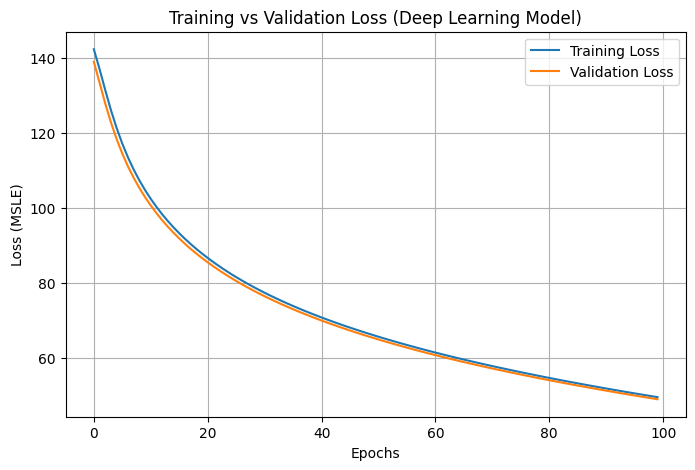

In [53]:
import matplotlib.pyplot as plt

# Training and validation loss curves
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (Deep Learning Model)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSLE)')
plt.legend()
plt.grid(True)
plt.show()


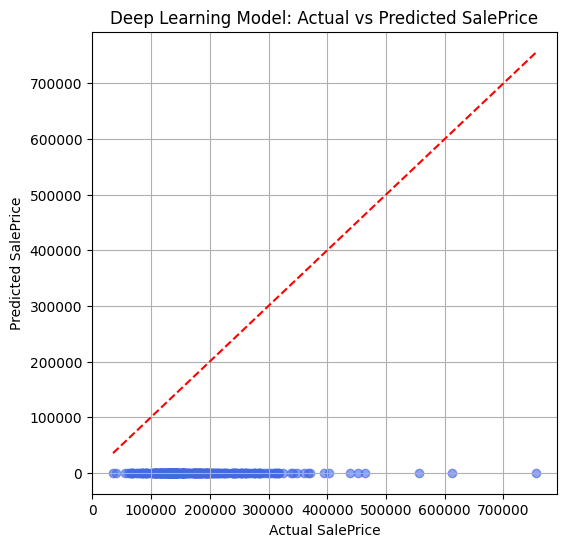

In [54]:
plt.figure(figsize=(6,6))
plt.scatter(y_valid, preds_dl, alpha=0.6, color='royalblue')
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Deep Learning Model: Actual vs Predicted SalePrice")
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--')
plt.grid(True)
plt.show()


In [55]:
import pandas as pd

# Comparison results of the two models
comparison = pd.DataFrame({
    'Model': ['Random Forest Regressor', 'Neural Network (Deep Learning)'],
    'Type': ['Traditional ML', 'Deep Learning'],
    'RMSLE': [0.1531, rmsle_dl],
    'Remarks': [
        'High accuracy, handles mixed data well',
        'Underperformed; limited data and no categorical encoding'
    ]
})
display(comparison)


,Model,Type,RMSLE,Remarks
0,Random Forest Regressor,Traditional ML,0.153100,"High accuracy, handles mixed data well"
1,Neural Network (Deep Learning),Deep Learning,6.996481,Underperformed; limited data and no categorica...
